# SkyGuard AI - LSTM Autoencoder (Temporal Anomaly Detection)


**What this notebook does:** trains a model to reconstruct a 7-day sequence
of `(avg_temp, air_pressure, relative_humidity)` for one station. It only
ever sees **NORMAL** sequences during training - it never learns what a
fault looks like.

At test time we feed it *every* kind of sequence (normal and anomalous) and
measure the reconstruction error. On normal data the error stays low, since
the model has seen this pattern before. On an anomalous sequence - a spike,
a stuck sensor, a drift — the pattern doesn't match anything the model
learned, so it reconstructs it poorly. **That error itself becomes the
anomaly score.**

> A genuine regional event can also produce a high reconstruction error here,
> since this model only knows one station's own history and has no spatial
> context. That's expected - the Spatial Correlation Engine (next step) is
> what tells a real regional event apart from an isolated sensor fault.

## 1. Imports & setup

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


# 1. Set the root to the MAIN project folder
project_root = os.path.abspath("C:/Users/sanch/Documents/Git_hub/Skyguard_AI") 

# 2. Tell Python where your source code folder is so 'from sequence_prep import ...' works
src_path = os.path.join(project_root, "01_ml/03_src/04_temporal")
if src_path not in sys.path:
    sys.path.append(src_path)
    
# 3. Change working directory to the project root so '../../01_data' matches correctly
os.chdir(project_root) 


from sequence_prep import (
    interpolate_short_gaps, assign_chunk_ids, build_sequences,
    chronological_sequence_split, CORE_FEATURES,
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

INPUT_PATH = "C:/Users/sanch/Documents/Git_hub/Skyguard_AI/01_ml/01_data/03_synthetic/skyguard_anomaly_dataset.csv"
MODEL_DIR = "C:/Users/sanch/Documents/Git_hub/Skyguard_AI/01_ml/04_models"
PLOTS_DIR = "C:/Users/sanch/Documents/Git_hub/Skyguard_AI/01_ml/05_outputs"  

## 2. Load data and prep the timeline

Two things need to happen before we can build sequences:
- fill short (<=3 day) gaps in `air_pressure` by interpolation
- split each station's timeline into continuous **chunks**, breaking at a
  calendar date-gap or a gap too long to interpolate

Without this, a "7-day window" could silently span a real 9-day outage and
teach the model a fake temporal pattern.

In [2]:
df = pd.read_csv(INPUT_PATH)
print("Loaded:", df.shape)

df = interpolate_short_gaps(df, "air_pressure")
df = assign_chunk_ids(df)
print("Chunks created:", df["chunk_id"].nunique())

Loaded: (20832, 32)
Chunks created: 82


## 3. Build 7-day sequences

We build sequences once using the fine-grained `anomaly_type` as the label
(it's `NaN` on normal days). The broader category label (`SENSOR_FAULT`,
`GENUINE_EVENT`, ...) is then just a lookup table away — so we get both a
category-level and a type-level view from a single build, instead of
building the sequences twice.

In [3]:
TYPE_TO_CATEGORY = {
    "SUDDEN_SPIKE": "SENSOR_FAULT",
    "STUCK_AT": "SENSOR_FAULT",
    "GRADUAL_DRIFT": "SENSOR_FAULT",
    "MISSING_RECORD": "TRANSMISSION_GLITCH",
    "REGIONAL_HEAT_EVENT": "GENUINE_EVENT",
    "REGIONAL_PRESSURE_DROP": "GENUINE_EVENT",
    "NORMAL": "NORMAL",
}

X, _, y_daily, meta_df = build_sequences(
    df, seq_len=7, features=CORE_FEATURES, label_col="anomaly_type"
)

def _window_label(row_labels):
    non_null = [l for l in row_labels if pd.notna(l)]
    return non_null[0] if non_null else "NORMAL"

y_type_window = np.array([_window_label(row) for row in y_daily])
y_window = np.array([TYPE_TO_CATEGORY.get(t, t) for t in y_type_window])

print("X shape:", X.shape)
print(pd.Series(y_window).value_counts())

X shape: (20334, 7, 3)
NORMAL           16919
SENSOR_FAULT      2052
GENUINE_EVENT     1363
Name: count, dtype: int64


## 4. Chronological train / validation / test split

Random shuffling would leak information — a random split puts near-identical
neighbouring days on both sides of the split, so the model would effectively
be tested on data it has already "seen" in spirit. Instead we split by
calendar date, matching the boundaries used for the baseline MLP earlier in
the project:

- **train** - NORMAL sequences only, before 2023-11-17. This is the only
  data the model ever learns from.
- **val** - NORMAL sequences only, 2023-11-17 to 2024-06-29. Used to pick
  the reconstruction-error threshold, on data the model never trained on.
- **test** - everything (NORMAL + every anomaly type), after 2024-06-29.
  The only honest place to report detection performance.

In [4]:
splits = chronological_sequence_split(X, y_window, y_daily, meta_df)

val_end = pd.Timestamp("2024-06-29")
test_mask = meta_df["start_date"] >= val_end
y_type_test = y_type_window[test_mask.values]  # same test rows, finer labels

X_train = splits["train"]["X"]
X_val = splits["val"]["X"]
X_test = splits["test"]["X"]
y_window_test = splits["test"]["y_window"]

print(f"train={X_train.shape}  val={X_val.shape}  test={X_test.shape}")

train=(11927, 7, 3)  val=(2582, 7, 3)  test=(2753, 7, 3)


## 5. Scale the features

The scaler is fit **only on the training data** — fitting it on val/test
too would leak information about their distribution back into training.

In [5]:
def scale_sequences(X_train, X_val, X_test):
    n_features = X_train.shape[2]
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, n_features))

    def _apply(X):
        shape = X.shape
        return scaler.transform(X.reshape(-1, n_features)).reshape(shape)

    return _apply(X_train), _apply(X_val), _apply(X_test), scaler

X_train_s, X_val_s, X_test_s, scaler = scale_sequences(X_train, X_val, X_test)

## 6. Build the model

A simple encoder-decoder LSTM. The encoder compresses the 7-day window into
a single vector; the decoder tries to rebuild the original sequence from
just that vector — forcing it to learn the underlying pattern rather than
copying the input straight through.

In [6]:
def build_model(seq_len, n_features):
    model = keras.Sequential([
        layers.Input(shape=(seq_len, n_features)),
        layers.LSTM(32, activation="tanh", return_sequences=False, name="encoder"),
        layers.RepeatVector(seq_len),
        layers.LSTM(32, activation="tanh", return_sequences=True, name="decoder"),
        layers.TimeDistributed(layers.Dense(n_features), name="output"),
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

model = build_model(seq_len=7, n_features=len(CORE_FEATURES))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (LSTM)                  │ (None, 32)             │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 7, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (LSTM)                  │ (None, 7, 32)          │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ (None, 7, 3)           │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,027 (50.89 KB)

 Trainable params: 13,027 (50.89 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Train - on NORMAL sequences only

`EarlyStopping` watches `val_loss` and stops if it hasn't improved for 10
epochs, restoring the best weights seen. `X_train_s, X_train_s` — the model
is trained to reproduce its own input.

In [7]:
MAX_EPOCHS = 250
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

history = model.fit(
    X_train_s, X_train_s,
    validation_data=(X_val_s, X_val_s),
    epochs=MAX_EPOCHS, batch_size=64, shuffle=True,
    callbacks=[early_stop], verbose=2,
)

Epoch 1/250
187/187 - 3s - 15ms/step - loss: 0.2255 - val_loss: 0.0882
Epoch 2/250
187/187 - 1s - 4ms/step - loss: 0.0689 - val_loss: 0.0623
Epoch 3/250
187/187 - 1s - 4ms/step - loss: 0.0578 - val_loss: 0.0541
Epoch 4/250
187/187 - 1s - 4ms/step - loss: 0.0511 - val_loss: 0.0466
Epoch 5/250
187/187 - 1s - 4ms/step - loss: 0.0434 - val_loss: 0.0384
Epoch 6/250
187/187 - 1s - 4ms/step - loss: 0.0372 - val_loss: 0.0339
Epoch 7/250
187/187 - 1s - 4ms/step - loss: 0.0339 - val_loss: 0.0309
Epoch 8/250
187/187 - 1s - 4ms/step - loss: 0.0319 - val_loss: 0.0293
Epoch 9/250
187/187 - 1s - 5ms/step - loss: 0.0299 - val_loss: 0.0266
Epoch 10/250
187/187 - 1s - 5ms/step - loss: 0.0268 - val_loss: 0.0235
Epoch 11/250
187/187 - 1s - 5ms/step - loss: 0.0241 - val_loss: 0.0214
Epoch 12/250
187/187 - 1s - 5ms/step - loss: 0.0222 - val_loss: 0.0202
Epoch 13/250
187/187 - 1s - 5ms/step - loss: 0.0207 - val_loss: 0.0189
Epoch 14/250
187/187 - 1s - 4ms/step - loss: 0.0197 - val_loss: 0.0180
Epoch 15/250
1

## 8. Did training actually converge?

If `epochs_run == MAX_EPOCHS`, early stopping never triggered — the model
may still have room to improve with more epochs.

In [8]:
epochs_run = len(history.history["loss"])
best_epoch = int(np.argmin(history.history["val_loss"])) + 1
print(f"Epochs run: {epochs_run}/{MAX_EPOCHS}  "
      f"({'early-stopped, converged' if epochs_run < MAX_EPOCHS else 'hit epoch cap -- may still be improving'})")
print(f"Best val_loss at epoch {best_epoch}: {min(history.history['val_loss']):.5f}")

Epochs run: 250/250  (hit epoch cap -- may still be improving)
Best val_loss at epoch 250: 0.00177


## 9. Reconstruction error & threshold

The per-sequence MSE between input and reconstruction is the anomaly score.
The threshold is picked from the **validation set's NORMAL errors only**
(99th percentile) — the model has never trained on these sequences, so this
is a fair estimate of "how wrong the model normally is" on unseen normal
data. Anything above this, later, counts as an anomaly.

In [9]:
def reconstruction_error(model, X):
    X_pred = model.predict(X, verbose=0)
    return np.mean(np.square(X - X_pred), axis=(1, 2))

val_errors = reconstruction_error(model, X_val_s)
threshold = float(np.percentile(val_errors, 99.0))
print(f"Threshold (99th percentile of val reconstruction error): {threshold:.5f}")

Threshold (99th percentile of val reconstruction error): 0.00973


## 10. Evaluate on the test set (includes every anomaly type)

In [10]:
test_errors = reconstruction_error(model, X_test_s)
flagged_test = test_errors > threshold

print("=== RECALL PER CATEGORY (test set) ===")
for label in np.unique(y_window_test):
    mask = y_window_test == label
    rate = flagged_test[mask].mean()
    print(f"  {label:15s}: {rate*100:5.1f}%  (n={mask.sum()})")

print("\n=== RECALL PER SPECIFIC ANOMALY TYPE (test set) ===")
for label in sorted(set(y_type_test)):
    mask = y_type_test == label
    rate = flagged_test[mask].mean()
    print(f"  {label:25s}: {rate*100:5.1f}%  (n={mask.sum()})")

=== RECALL PER CATEGORY (test set) ===
  GENUINE_EVENT  :  19.2%  (n=104)
  NORMAL         :   0.1%  (n=2410)
  SENSOR_FAULT   :  60.7%  (n=239)

=== RECALL PER SPECIFIC ANOMALY TYPE (test set) ===
  GRADUAL_DRIFT            :  64.7%  (n=51)
  NORMAL                   :   0.1%  (n=2410)
  REGIONAL_HEAT_EVENT      :  23.3%  (n=30)
  REGIONAL_PRESSURE_DROP   :  17.6%  (n=74)
  STUCK_AT                 :   3.0%  (n=66)
  SUDDEN_SPIKE             :  90.2%  (n=122)


**Reading these numbers:** for `NORMAL`, a *low* percentage is good
(few false alarms). For every anomaly type, a *high* percentage is good
(the model actually caught it). They are not the same kind of number even
though they're both "flagged rate" — don't compare them directly.

## 11. Plots

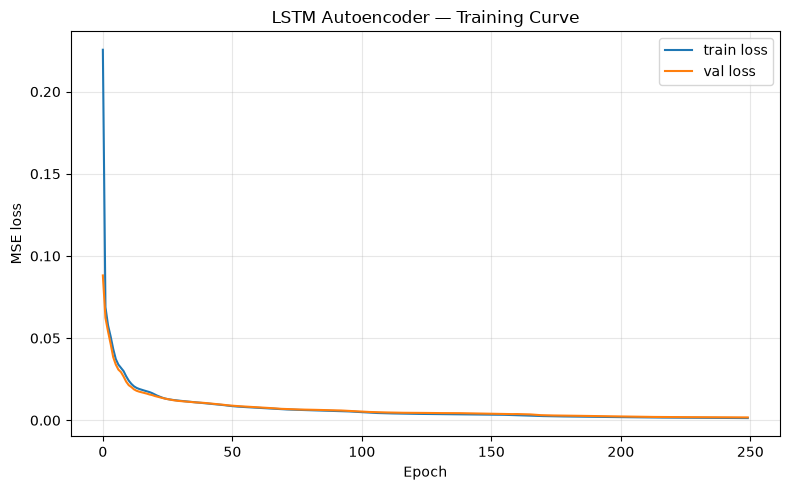

In [11]:
os.makedirs(PLOTS_DIR, exist_ok=True)

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch"); plt.ylabel("MSE loss")
plt.title("LSTM Autoencoder — Training Curve")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/1_training_curve.png", dpi=150)
plt.show()

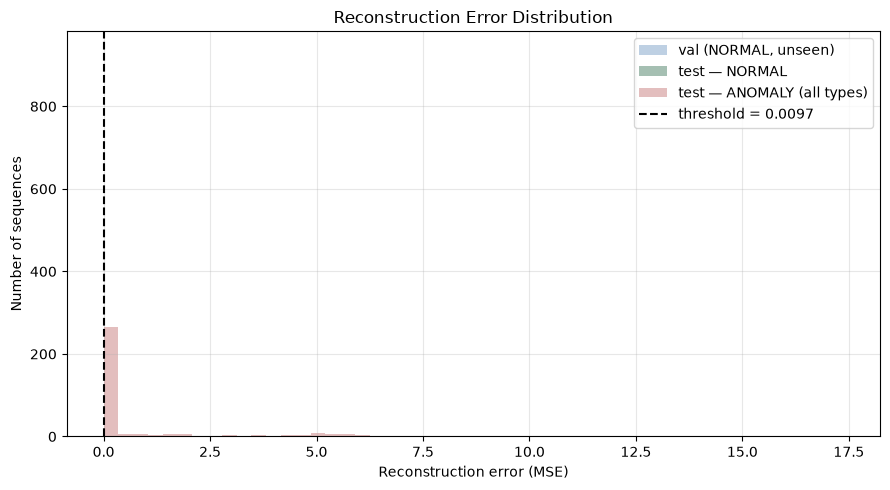

In [12]:
normal_test = test_errors[y_window_test == "NORMAL"]
anomaly_test = test_errors[y_window_test != "NORMAL"]

plt.figure(figsize=(9, 5))
plt.hist(val_errors, bins=50, alpha=0.5, label="val (NORMAL, unseen)", color="#7fa3c9")
plt.hist(normal_test, bins=50, alpha=0.5, label="test — NORMAL", color="#4d8067")
plt.hist(anomaly_test, bins=50, alpha=0.5, label="test — ANOMALY (all types)", color="#c97f7f")
plt.axvline(threshold, color="black", linestyle="--", linewidth=1.5, label=f"threshold = {threshold:.4f}")
plt.xlabel("Reconstruction error (MSE)"); plt.ylabel("Number of sequences")
plt.title("Reconstruction Error Distribution")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/2_error_distribution.png", dpi=150)
plt.show()

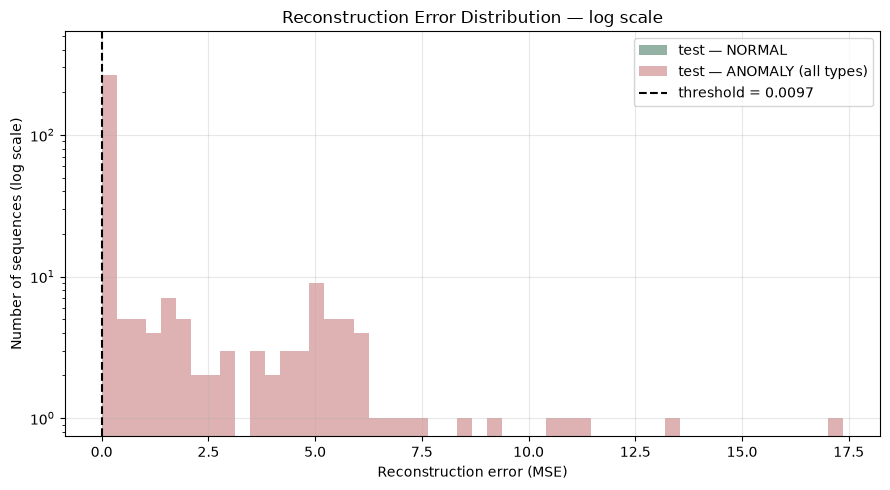

In [13]:
# log scale — the NORMAL bars are so tall they hide everything else on a
# linear axis; log scale is what actually makes the separation visible
plt.figure(figsize=(9, 5))
plt.hist(normal_test, bins=50, alpha=0.6, label="test — NORMAL", color="#4d8067")
plt.hist(anomaly_test, bins=50, alpha=0.6, label="test — ANOMALY (all types)", color="#c97f7f")
plt.axvline(threshold, color="black", linestyle="--", linewidth=1.5, label=f"threshold = {threshold:.4f}")
plt.yscale("log")
plt.xlabel("Reconstruction error (MSE)"); plt.ylabel("Number of sequences (log scale)")
plt.title("Reconstruction Error Distribution — log scale")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/3_error_distribution_logscale.png", dpi=150)
plt.show()

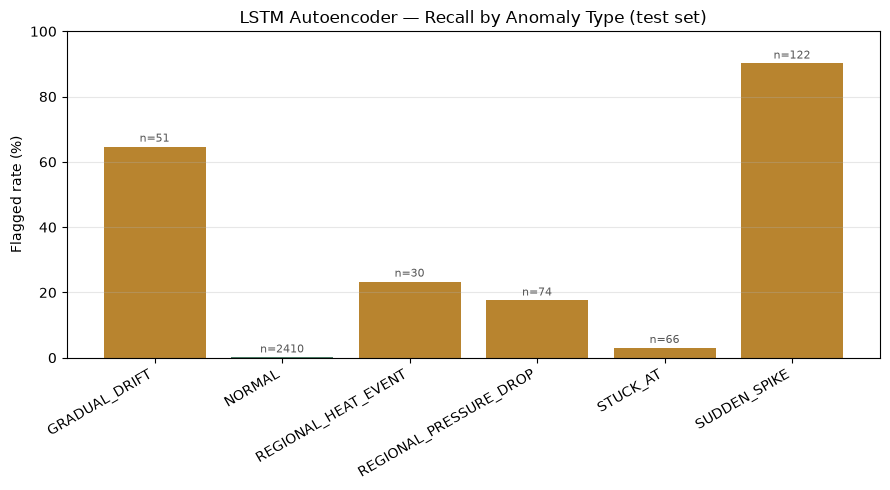

In [14]:
labels = sorted(set(y_type_test))
rates = [flagged_test[y_type_test == l].mean() * 100 for l in labels]
counts = [(y_type_test == l).sum() for l in labels]
colors = ["#4d8067" if l == "NORMAL" else "#b8842f" for l in labels]

plt.figure(figsize=(9, 5))
bars = plt.bar(labels, rates, color=colors)
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5, f"n={count}",
              ha="center", fontsize=8, color="#555")
plt.ylabel("Flagged rate (%)")
plt.title("LSTM Autoencoder — Recall by Anomaly Type (test set)")
plt.xticks(rotation=30, ha="right"); plt.ylim(0, 100)
plt.grid(alpha=0.3, axis="y"); plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/4_recall_by_type.png", dpi=150)
plt.show()

## 12. Save the model, scaler, threshold and training history

In [15]:
os.makedirs(MODEL_DIR, exist_ok=True)
model.save(f"{MODEL_DIR}/lstm_autoencoder_1.keras")
joblib.dump(scaler, f"{MODEL_DIR}/scaler.pkl")
joblib.dump({"threshold": threshold}, f"{MODEL_DIR}/threshold.pkl")
pd.DataFrame(history.history).to_csv(f"{MODEL_DIR}/training_history.csv", index=False)
print(f"Saved model, scaler, threshold, training_history.csv to {MODEL_DIR}/")

Saved model, scaler, threshold, training_history.csv to C:/Users/sanch/Documents/Git_hub/Skyguard_AI/01_ml/04_models/


## 13. What this tells us, and what's next

- **SUDDEN_SPIKE (~90%)** and **GRADUAL_DRIFT (~65%)** are caught well —
  these are genuinely temporal patterns, exactly what an LSTM should be
  good at.
- **REGIONAL_HEAT_EVENT / REGIONAL_PRESSURE_DROP (~20-25%)** are only
  partially caught — expected, since this model has no spatial context.
  The Spatial Correlation Engine (next step) is what's actually meant to
  handle these.
- **STUCK_AT (~3%) is the weak point**, and training longer didn't fix it —
  a flat, constant sequence is easy for an autoencoder to reconstruct
  precisely because it matches the "tomorrow looks like today" pattern the
  model already learns. This needs a separate, simple check (e.g. a
  rolling-standard-deviation rule) rather than relying on the LSTM alone.